<h1 style="font-size:30px;">Aerial Drone Imagery Segmentation using SegFormer</h1>

In recent years, the field of computer vision has witnessed significant advancements, particularly in the realm of semantic segmentation. Aerial drone imagery, with its vast applications in areas such as surveillance, mapping, and environmental monitoring, presents a unique set of challenges and opportunities for semantic segmentation tasks.

In this notebook we will explore the process of learning how to perform semantic segmentation on an aerial drone dataset. For the purpose of this notebook, we will leverage the capabilities of SegFormer, a transformer-based model that has demonstrated impressive performance in semantic segmentation tasks. Transformers, originally introduced in the context of natural language processing, have recently been adapted to computer vision tasks with great success.

<img src="https://opencv.org/wp-content/uploads/2023/06/c2_m4_aerial_project_Cover-scaled.jpg" width="100%" align="center">


To use SegFormer, we will harness the ***HuggingFace `transformers`*** package, a widely-used library for transformer-based models. This package offers pre-trained models that can be readily loaded and fine-tuned on custom datasets. By leveraging the pre-trained weights, we can benefit from the model's learned representations and accelerate the training process on our specific aerial drone dataset.

During the training phase, we will employ a custom loss function (Dice + Cross Entropy) a popular choice for semantic segmentation tasks. Furthermore, evaluating the performance of our model is crucial to gauge its effectiveness. In addition to traditional metrics such as accuracy we will employ intersection over union (IoU) as evaluation metrics.

In [ ]:
# Install libraries and restart kernel.

!pip install -qqqU wandb transformers==5.0.0 albumentations torchmetrics torchinfo tqdm deepml

In [4]:
import gc
import os
import random
import zipfile
import warnings
from glob import glob
from dataclasses import dataclass

import cv2
import PIL
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.cuda import amp
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import SegformerImageProcessor
from transformers import SegformerForSemanticSegmentation

from torchinfo import summary

# For data augmentation and preprocessing.
import albumentations as A
from albumentations.pytorch import ToTensorV2

# To filter UserWarning.
warnings.filterwarnings("ignore", category=UserWarning)

## 1 Download and Extract Aerial Drone Dataset


The Semantic Segmentation <a href="https://ivc.tugraz.at/research-project/semantic-drone-dataset/">Drone Dataset</a> is an Aerial Drone dataset developed by Institute of Computer Graphics and Vision at Tu Graz university, Austria.


> The Semantic Drone Dataset focuses on semantic understanding of urban scenes for increasing the safety of autonomous drone flight and landing procedures. The imagery depicts  more than 20 houses from nadir (bird's eye) view acquired at an altitude of 5 to 30 meters above ground. A high resolution camera was used to acquire images at a size of 6000x4000px (24Mpx). The training set contains 400 publicly available images and the test set is made up of 200 private images.


<img src="https://opencv.org/wp-content/uploads/2023/06/c2_m4_aerial_project_dataset_image.jpg" width="100%" align=center>

The dataset contains images of from 24 classes as follows:

<img src="https://opencv.org/wp-content/uploads/2023/06/c2_m4_aerial_project_dataset_color_code.jpg" width="50%" align=center>

---

We've resized the original dataset while maintaining the aspect ratio. The new dimensions (H, W) are (1000, 1500). This also reduces the download file size from 4GB to ≈330MB. We've also split the dataset into training and validation set before hand.

The dataset has the following file structure:

```html
aerial_dataset_resized
    ├── train
    │   ├── images  [340 samples]
    │   └── masks   [340 samples]
    ├── valid
    │    ├── images [60 samples]
    │    └── masks  [60 samples]
    │
    └── class_dict_seg.csvmasks
```

In [5]:
# To download and unzip processed dataset.

def download_and_unzip(url, save_path):

    print("Downloading and extracting assets...", end="")
    file = requests.get(url)
    open(save_path, "wb").write(file.content)

    try:
        with zipfile.ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0]) # Unzip where downloaded.
            print("Done")
    except:
        print("Invalid file")

In [6]:
URL = r"https://www.dropbox.com/s/5lhjkl4ilojg9cr/aerial_dataset_resized.zip?dl=1"

dataset_name = "aerial_dataset_resized"
dataset_zip_path = os.path.join(os.getcwd(), f"{dataset_name}.zip")
dataset_path = os.path.join(os.getcwd(), dataset_name)

# Download if dataset does not exists.
if not os.path.exists(dataset_path):
    download_and_unzip(URL, dataset_zip_path)
    # shutil.rmtree(dataset_zip_path) # Remove the ZIP file to free storage space.

Load the class to RGB Color CSV file. We can see that there are 24 classes in the dataset. The class 0 i.e., `unlabled` is treated as *background class*.

In [7]:
class_df = pd.read_csv(os.path.join(dataset_path, "class_dict_seg.csv"))

NUM_CLASSES = len(class_df)

class_df

,name,r,g,b
0,unlabeled,0,0,0
1,paved-area,128,64,128
2,dirt,130,76,0
3,grass,0,102,0
4,gravel,112,103,87
5,water,28,42,168
6,rocks,48,41,30
7,pool,0,50,89
8,vegetation,107,142,35
9,roof,70,70,70


## 2 Configuration Setup

### 2.1 Device Selection & Benchmarking Behaviour

In [8]:
def get_default_device():
    gpu_available = torch.cuda.is_available()
    return torch.device('cuda' if gpu_available else 'cpu'), gpu_available

In [9]:
def seed_everything(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### 2.2 Training and Dataset Configurations

The original size of the images in the dataset is 1000 x 1500. For our experiment, we've tried 2 image sizes (384, 576) & (341, 512). Both chosen shapes ensure the aspect ratio is maintained. We achieved the best result when the whole image was reshaped to size (384 576). This indicates that using bigger image sizes is beneficial for tasks like semantic segmentation, as there are more details to work with.

Other common approaches are to take random crops of a specific size from the original image and train on the fly or create a dataset of cropped patches of images beforehand.

**Note** The notebook was run on Nvidia 4090TI GPUs. If you are facing CUDA related memory issues, try the following:
1. Reduce either the batch size as provided in the comments.
2. Reduce image size as provided in the comments.
3. Use a smaller model such as `"nvidia/segformer-b2-finetuned-ade-512-512"` or `"nvidia/segformer-b1-finetuned-ade-512-512"`

You can very well try all three in any combination you prefer. I would recommend to start with a smaller model.

In [10]:
@dataclass
class DatasetConfig:
    NUM_CLASSES: int = NUM_CLASSES
    IMG_WIDTH:   int = 576
    IMG_HEIGHT:  int = 384

    DATA_TRAIN_IMAGES: str = os.path.join(dataset_path, "train", "images", r"*.jpg")
    DATA_TRAIN_LABELS: str = os.path.join(dataset_path, "train", "masks",  r"*.png")
    DATA_VALID_IMAGES: str = os.path.join(dataset_path, "valid", "images", r"*.jpg")
    DATA_VALID_LABELS: str = os.path.join(dataset_path, "valid", "masks",  r"*.png")

    MEAN: tuple = (0.485, 0.456, 0.406)
    STD:  tuple = (0.229, 0.224, 0.225)

    BACKGROUND_CLS_ID: int = 0

@dataclass
class TrainingConfig:
    BATCH_SIZE:      int = 12
    NUM_EPOCHS:      int = 50
    LEARNING_RATE: float = 3e-4
    NUM_WORKERS:     int = 8
    WEIGHT_DECAY:  float = 1e-4


@dataclass
class InferenceConfig:
    BATCH_SIZE:  int = 6
    NUM_BATCHES: int = 2

@dataclass
class ModelConfig:
    MODEL_NAME:str = "nvidia/segformer-b3-finetuned-ade-512-512" # The SegFormer model variant path to use
                                                                 # from HuggingFace

### 2.3 Initiaze WandB

In [11]:
from google.colab import userdata
import wandb

secretName = 'wandb_google_colab_api_key'
wandb.login(userdata.get(secretName))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sagar100rathod to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [12]:
run = wandb.init(project="Aerial-Drone-Imagery-Segmentation",
                 name="Segformer")

In [13]:
# Initialize experiment run configurations

from wandb.sdk.wandb_config import Config


HPARAMS: Config = run.config

HPARAMS.IMG_SIZE      = (DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH)
HPARAMS.MODEL_NAME    = ModelConfig.MODEL_NAME
HPARAMS.BATCH_SIZE    = TrainingConfig.BATCH_SIZE
HPARAMS.NUM_EPOCHS    = TrainingConfig.NUM_EPOCHS

HPARAMS.OPTIMIZER     = "AdamW"
HPARAMS.LEARNING_RATE = TrainingConfig.LEARNING_RATE
HPARAMS.WEIGHT_DECAY  = TrainingConfig.WEIGHT_DECAY
HPARAMS.LR_SCHEDULER  = "MultiStepLR"

## 3 Custom Dataset Class

In this section, we are defining our own custom `Dataset` class `CustomSegDataset`. In the  `CustomSegDataset` class, we make use of the famous <a href="https://albumentations.ai/" target="_blank">Albumentations library</a> to apply augmentations to image-mask pairs at the same time. This is necessary in case of geometric augmentations are applied to the training set, in that case, the masks should also be adjusted appropriately.

**Class Methods**: There are 3 required method which needs to be defined in the custom dataset class.

1. `__init__()`: This is the first required method we need to define. In this method, we initialize all the variables we need in the entire class for preparing the dataset. In case of segmentation, this includes the input image paths (`image_paths`) and segmentation masks (`mask_paths`) which are the lists containing the paths to all the images and masks. Along with that, we define the total number of classes and boolean to indicate whether the images and masks belong to the train set or not and the custom image preprocessor of the HuggingFace model.
 * Note that the number of classes `num_classes` is not specifically used but is a good attribute to include in the class as a reference. We also have defined one additional class variable `self.transforms` which holds the necessary preprocessing and augmentation functions to be applied to images and masks.


2. `__len__()`: This is the second required method. This method is used to return the total number of image-mask pairs.


3. `load_file()`: The `load_file()` method is used to load the image or mask from disk and resize it according to the new size `self.image_size`.


4. `setup_transforms()`: This method contains the preprocessing and augmentations that we want to apply to the images and masks. It returns an "container" holding all the functions to be applied in-order.


5.  `__getitem__()`: This is the third required method. Here, the value of the `index` argument keeps increasing. So, on the first iteration, the value is 0, on the second iteration, it is 1, and so on. Inside the function, the following operations are performed in order.
    1. Get the `image_path` and `mask_path` at the `index`.
    2. Load `image` and `mask`.
    3. Then we convert the RGB mask mask images to grayscale images using the `rgb_to_grayscale(...)` function.
    4. Finally, we apply the required preprocessing (and augmemtation in case of training set) transformation and return the image-mask pair.

Each model loaded from HuggingFace generally requires its own set of preprocessing methods that need to be used. In case of the SegFormer model, there's <a href="https://huggingface.co/docs/transformers/model_doc/segformer#transformers.SegformerImageProcessor" target="_blank">SegformerImageProcessor</a> class we can use to apply the preprocessing transformations.

Coincidentally, for SegFormer, the preprocessing transforms are similar to the ones we generally use as well, such as resizing, rescaling, normalization, and changing label ids. The `SegformerImageProcessor` class provides a `.preprocess(...)` method that abstracts away all this code and functionality for us in a single call.

You can find more details in the methods's <a href="https://huggingface.co/docs/transformers/model_doc/segformer#transformers.SegformerImageProcessor.preprocess" target="_blank">documentation page.</a>

---

In the `__getitem__()` method below, the `if` block is used for processing training and validation image and mask, whereas the `else` block will be used in cases where only images are available.

We've used the `.preprocess(...)` in two ways.

1. In the `if` block, we use the `.preprocess(...)` method to only resize the image and mask. The outputs are further
processed using the Albumentations library to apply appropriate transformations.

```python
encoded_inputs = self.processor.preprocess(images=image, segmentation_maps=mask, resample=2,
                                           return_tensors="np", data_format="channels_last"
                                          )
```
   
2. In the second case, we use it to preprocess images. This is a more general way to use the method.

```python
encoded_inputs = self.processor.preprocess(images=image, do_rescale=True, rescale_factor=1.0 / 255,
                                           return_tensors="pt", resample=2, do_normalize=True,
                                           image_mean=DatasetConfig.MEAN,
                                           image_std=DatasetConfig.STD
                                          )
```

In [14]:
# Custom Class for creating training and validation (segmentation) dataset objects.

class CustomSegDataset(Dataset):
    def __init__(self, *, num_classes, image_paths, mask_paths=None, is_train=False, processor=None):

        self.image_paths = image_paths
        self.mask_paths  = mask_paths  # None in case of test set where only images are available.
        self.num_classes = num_classes
        self.processor   = processor  # SegFormer ImageProcessor instance.
        self.is_train    = is_train
        self.transforms  = self.setup_transforms()


    def __len__(self):
        return len(self.image_paths)


    def setup_transforms(self):
        transforms = []

        # Augmentation to be applied to the training set.
        if self.is_train:
            transforms.extend([
                    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
                    A.ShiftScaleRotate(scale_limit=0.2, rotate_limit=0.2, shift_limit=0.3, p=0.5),
            ])

        # Preprocess transforms - Normalization and converting to PyTorch tensor format (HWC --> CHW).
        transforms.extend([
                A.Normalize(mean=DatasetConfig.MEAN, std=DatasetConfig.STD, always_apply=True),
                ToTensorV2(),  # (H, W, C) --> (C, H, W)
        ])
        return A.Compose(transforms)


    def load_file(self, file_path):
        file = Image.open(file_path).convert("RGB")
        return file


    def __getitem__(self, index):
        if self.mask_paths:  # True for Training and validation set.

            # Load image and mask file.
            image = self.load_file(self.image_paths[index])
            mask  = self.load_file(self.mask_paths[index])


            # Process inputs according the model's ImageProcessor.
            # This is one way to use it. We've used the more common for the test set.
            encoded_inputs = self.processor.preprocess(images=image, segmentation_maps=mask, resample=PIL.Image.Resampling.NEAREST,
                                                       return_tensors="np", data_format="channels_last",
                                                       input_data_format='channels_last')

            # Removing the extra batch dimension added in the previous step.
            image, mask = encoded_inputs["pixel_values"].squeeze(axis=0), encoded_inputs["labels"].squeeze(axis=0)

            #print("image:", image.shape, "mask:", mask.shape)

            # Used for converting RGB mask to a single channel (grayscale) representation.
            # Each value of the singe channel mask represents the pixel's class ID (essentially
            # collapsing the RGB mask into a single channel mask).
            # Shape: (H, W, C) --> (H, W)
            mask = rgb_to_grayscale(mask, color_map=rev_id2color, background_cls_id=DatasetConfig.BACKGROUND_CLS_ID)

            # Apply Preprocessing (+ Augmentations) transformations to image-mask pair
            transformed = self.transforms(image=image, mask=mask)
            image, mask = transformed["image"], transformed["mask"].to(torch.long)
            return image, mask.to(torch.long)

        else:  # For Test set or when only images are available.

            # Load image.
            image = self.load_file(self.image_paths[index])

            # Preprocess the image directly by using the
            # model's custom image processor
            encoded_inputs = self.processor.preprocess(
                images=image,
                return_tensors="pt", # Return pytorch tensor.
                do_rescale=True,
                rescale_factor=1.0 / 255,
                do_normalize=True,
                image_mean=DatasetConfig.MEAN,
                image_std=DatasetConfig.STD,
                resample=Image.Resampling.NEAREST,
                input_data_format='channels_last'
            )

            # Apply in-place removal of batch dimension.
            image = encoded_inputs["pixel_values"].squeeze_()

            return image

## 4 Utilities and Helper Functions


In this section, we define several utilities and helper functions that will be used further below.

We start by creating a class ID to color mapping dictionaries. The first dictionary defines the color mapping  from class IDs to RGB colors in the original dataset. It is used to map the RGB ground truth masks into a single channel representation that encodes the class IDs.
The second dictionary holds the mapping from RGB colors to class ID's used for converting RGB masks to grayscale masks.

In [15]:
# Create a mapping of class ID to RGB value.
id2color = {idx: (row[1], row[2], row[3]) for idx, row in class_df.iterrows()}

# del id2color[23] # To remove the 'conflicting' class.

DatasetConfig.NUM_CLASSES = len(id2color)

HPARAMS.NUM_CLASSES = DatasetConfig.NUM_CLASSES

print("Updated number of classes", HPARAMS.NUM_CLASSES)

# Re-adding the reverse mapping, which is essential for rgb_to_grayscale
rev_id2color = {value: key for key, value in id2color.items()}

Updated number of classes 24


/tmp/ipykernel_5544/3954499748.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  id2color = {idx: (row[1], row[2], row[3]) for idx, row in class_df.iterrows()}


When preparing the masks in the custom dataset class, we need to convert the RGB images to it's single channel (grayscale) representation where each pixel value corresponds to the class ID of the pixel. The following function performs this conversion.

In [16]:
# Function to convert RGB mask to grayscale labels.
def rgb_to_grayscale(rgb_arr, color_map = rev_id2color, background_cls_id=0):

    # Create empty mask
    h, w = rgb_arr.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    # Vectorized mapping
    flat_img = rgb_arr.reshape((-1, 3))
    flat_mask = np.zeros(flat_img.shape[0], dtype=np.uint8)

    for color, idx in color_map.items():
        matches = np.all(flat_img == color, axis=1)
        flat_mask[matches] = idx

    mask = flat_mask.reshape(h, w)

    return mask

We will also need to make use of the function below that will convert a single channel mask to an RGB representation for visualization purposes. Each class ID in the single-channel mask will be converted to a different color according to the `id2color` dictionary mapping.

In [17]:
# Function to convert a single channel mask representation to an RGB mask.
def num_to_rgb(num_arr, color_map=id2color):
    single_layer = np.squeeze(num_arr)
    output = np.zeros(num_arr.shape[:2] + (3,))

    for k in color_map.keys():
        output[single_layer == k] = color_map[k]

    return np.float32(output) / 255.0 # return a floating point array in range [0.0, 1.0]

Helper function to overlay an RGB segmentation map on top of an RGB image.

In [18]:
# Function to overlay a segmentation map on top of an RGB image.
def image_overlay(image, segmented_image):

    alpha = 1.0 # Transparency for the original image.
    beta  = 0.7 # Transparency for the segmentation map.
    gamma = 0.0 # Scalar added to each sum.

    segmented_image = cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR)

    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    image = cv2.addWeighted(image, alpha, segmented_image, beta, gamma, image)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return np.clip(image, 0.0, 1.0)

The convenience function below will display the original image, the ground truth mask, and the ground truth mask overlayed on the original image. Note that there is an optional argument that allows you to control if the ground truth mask is displayed as a grayscale image or a color image.

In [19]:
def display_image_and_mask(*, images, masks, color_mask=False, color_map=id2color):
    title = ["GT Image", "GT Mask", "Color Mask", "Overlayed Mask"]

    for idx in range(images.shape[0]):
        image = images[idx]
        grayscale_gt_mask = masks[idx]

        fig = plt.figure(figsize=(15, 4))

        # Create RGB segmentation map from grayscale segmentation map.
        rgb_gt_mask = num_to_rgb(grayscale_gt_mask, color_map=color_map)

        # Create the overlayed image.
        overlayed_image = image_overlay(image, rgb_gt_mask)

        plt.subplot(1, 4, 1)
        plt.title(title[0])
        plt.imshow(image)
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.title(title[1])
        plt.imshow(grayscale_gt_mask, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.title(title[2])
        plt.imshow(rgb_gt_mask)
        plt.axis("off")

        plt.imshow(rgb_gt_mask)
        plt.subplot(1, 4, 4)
        plt.title(title[3])
        plt.imshow(overlayed_image)
        plt.axis("off")

        plt.show()

    return

## 5 Creating DataLoader Objects

Here we define the `get_dataloader(...)` function to generate training and validation data loader objects. We also create an instance of the `SegformerImageProcessor` class that is passed to the custom dataset class. The parameter values we've used can also be overridden later on when using the `.preprocess(...)` methods.

In [20]:
def get_dataloader(configs=None, num_workers=0, pin_memory=False, shuffle_validation=False, custom_batch_size=None):

    NUM_CLASSES    = configs["NUM_CLASSES"]
    BATCH_SIZE     = configs["BATCH_SIZE"] if not custom_batch_size else custom_batch_size
    HEIGHT, WIDTH  = configs["IMG_SIZE"][0], configs["IMG_SIZE"][1]

    # Initialize Custom image processor instance.
    processor = SegformerImageProcessor(
        do_resize=True,
        size={"height": HEIGHT, "width": WIDTH},
        do_rescale=False,
        do_normalize=False,
    )

    # Create training dataset and dataloader.
    train_images = sorted(glob(f"{DatasetConfig.DATA_TRAIN_IMAGES}"))
    train_masks  = sorted(glob(f"{DatasetConfig.DATA_TRAIN_LABELS}"))

    train_dataset = CustomSegDataset(image_paths=train_images, mask_paths=train_masks, is_train=True,
                                     num_classes=NUM_CLASSES, processor=processor)

    train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,  pin_memory=pin_memory,
                               num_workers=num_workers, drop_last=True, shuffle=True)

    # Create validation dataset and dataloader.
    valid_images = sorted(glob(f"{DatasetConfig.DATA_VALID_IMAGES}"))
    valid_masks  = sorted(glob(f"{DatasetConfig.DATA_VALID_LABELS}"))

    valid_dataset = CustomSegDataset(image_paths=valid_images, mask_paths=valid_masks, is_train=False,
                                     num_classes=NUM_CLASSES, processor=processor)

    valid_loader  = DataLoader(valid_dataset, batch_size=BATCH_SIZE,  pin_memory=pin_memory,
                               num_workers=num_workers, shuffle=shuffle_validation)

    return train_loader, valid_loader

Now we call the above function to create the `DataLoader` objects.

In [21]:
train_loader, valid_loader = get_dataloader(configs=HPARAMS, shuffle_validation=True)

### 5.1 Display Sample Images from the Dataset

In the code cell below, we loop over the first batch in the validation dataset and display the ground truth image, ground truth mask, and the ground truth mask overlayed on the image. The overlay helps us better visualize the segmented classes in the context of the original image.

In [22]:
# This function is used for reversing the Normalization step performed during image preprocessing.
# Note the mean and std values must match the ones used.

def denormalize(tensors, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """Normalization parameters for pre-trained PyTorch models
    Denormalizes image tensors using mean and std"""

    for c in range(3):
        tensors[:, c, :, :].mul_(std[c]).add_(mean[c])

    return torch.clamp(tensors, min=0.0, max=1.0)

In [23]:
for batch_images, batch_masks in valid_loader:
    print("batch_images shape:", batch_images.shape)
    print("batch_masks shape: ", batch_masks.shape)

    batch_images = denormalize(batch_images, mean=DatasetConfig.MEAN, std=DatasetConfig.STD).permute(0, 2, 3, 1).numpy()
    batch_masks  = batch_masks.numpy()

    display_image_and_mask(images=batch_images, masks=batch_masks, color_mask=True)

    break

Output hidden; open in https://colab.research.google.com to view.

## 6 Segformer Model

The SegFormer model was proposed in <a href="https://arxiv.org/abs/2105.15203" target="_blank">SegFormer: Simple and Efficient Design for Semantic Segmentation with Transformers</a>. The model consists of a hierarchical Transformer encoder and a lightweight all-MLP decode head to achieve great results on image segmentation benchmarks such as ADE20K and Cityscapes.

Abstract from the paper:

> We present SegFormer, a simple, efficient yet powerful semantic segmentation framework which unifies Transformers with lightweight multilayer perception (MLP) decoders. SegFormer has two appealing features: 1) SegFormer comprises a novel hierarchically structured Transformer encoder which outputs multiscale features. It does not need positional encoding, thereby avoiding the interpolation of positional codes which leads to decreased performance when the testing resolution differs from training. 2) SegFormer avoids complex decoders. The proposed MLP decoder aggregates information from different layers, and thus combining both local attention and global attention to render powerful representations. We show that this simple and lightweight design is the key to efficient segmentation on Transformers. We scale our approach up to obtain a series of models from SegFormer-B0 to SegFormer-B5, reaching significantly better performance and efficiency than previous counterparts. For example, SegFormer-B4 achieves 50.3% mIoU on ADE20K with 64M parameters, being 5x smaller and 2.2% better than the previous best method. Our best model, SegFormer-B5, achieves 84.0% mIoU on Cityscapes validation set and shows excellent zero-shot robustness on Cityscapes-C.

<img src="https://opencv.org/wp-content/uploads/2023/06/c2_m4_aerial_project_Segformer_architecture.png" width="75%" align="center">

Source: Arxiv paper

**You can check all the trained weights available for SegFormer model on HuggingFace <a href="https://huggingface.co/models?pipeline_tag=image-segmentation&sort=downloads&search=nvidia%2Fsegformer" target="_blank">over here.</a>**

Loading a pre-trained model version and getting it ready for inference or finetuning is very easy, thanks to HuggingFace. We only have to pass the following:

1. `pretrained_model_name_or_path`: (string). The id/path of a pre-trained model hosted on the Huggingface model zoo.
2. `num_labels`: (int) The number of channels (one for each class) we want the model to give as output. Suppose the number differs from the original number. In that case, the layer will be replaced with a new layer with randomly initialized weights.
3. `ignore_mismatched_sizes`: (bool) Boolean value to whether or not to ignore the weight key mismatch. Here, it occurs because we change the `num_labels` value.  

In [24]:
def get_model(configs):
    model = SegformerForSemanticSegmentation.from_pretrained(
        configs["MODEL_NAME"],
        num_labels=configs["NUM_CLASSES"],
        ignore_mismatched_sizes=True,
    )
    return model

**Usage**

In [25]:
# Define model
from transformers.models.segformer.modeling_segformer import SegformerForSemanticSegmentation

model: SegformerForSemanticSegmentation = get_model(HPARAMS)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/190M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b3-finetuned-ade-512-512
Key                           | Status   |                                                                                                    
------------------------------+----------+----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([24, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([24])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


* The model's forward pass takes multiple arguments <a href="https://huggingface.co/docs/transformers/v4.15.0/model_doc/segformer#transformers.SegformerForSemanticSegmentation.forward" target="_blank">[DOCUMENTATION]</a>. The two important ones are `pixel_values` and `labels`.

* The `pixel_values` argument refers to the input images. The `labels` argument is for passing the ground-truth mask.  

* The model's forward pass also calculates the cross-entropy loss if `labels` are passed.

* The output logits are smaller than the input image size. To get the outputs to match the input image size, we need to simply upsample it.

In [26]:
# Create dummy inputs.
data    = torch.randn(1, 3, *HPARAMS.IMG_SIZE)
target = torch.rand(1, *HPARAMS.IMG_SIZE).to(torch.long)

data.shape, target.shape

(torch.Size([1, 3, 384, 576]), torch.Size([1, 384, 576]))

In [27]:
outputs = model(pixel_values=data, labels=target, return_dict=True)

# Upsample model outputs to match input image size.
upsampled_logits = nn.functional.interpolate(outputs["logits"], size=target.shape[-2:], mode="bilinear", align_corners=False)

model.safetensors:   0%|          | 0.00/189M [00:00<?, ?B/s]

To access the model's output, we have to use the `["logits"]` key. Similarly, we can access the loss via the `"loss"` key.

In [28]:
print("Model Outputs: outputs['logits']:", outputs["logits"].shape)

print("Model Outputs Resized::", upsampled_logits.shape)

print("Loss: outputs['loss']:", outputs["loss"])

Model Outputs: outputs['logits']: torch.Size([1, 24, 96, 144])
Model Outputs Resized:: torch.Size([1, 24, 384, 576])
Loss: outputs['loss']: tensor(3.1331, grad_fn=<NllLoss2DBackward0>)


In this notebook, we won't be using the Cross-entropy loss returned by the model for training. Instead, in the next section, we are going to define our own custom combo loss function that combines Smooth Dice coefficient & CE to compute the loss.

In [29]:
summary(model, input_size=(1, 3, *HPARAMS["IMG_SIZE"]), col_names=["input_size", "output_size", "num_params"], device="cpu")

Layer (type:depth-idx)                                                      Input Shape               Output Shape              Param #
SegformerForSemanticSegmentation                                            [1, 3, 384, 576]          [1, 24, 96, 144]          --
├─SegformerModel: 1-1                                                       [1, 3, 384, 576]          [1, 64, 96, 144]          --
│    └─SegformerEncoder: 2-1                                                [1, 3, 384, 576]          [1, 64, 96, 144]          --
│    │    └─ModuleList: 3-10                                                --                        --                        (recursive)
│    │    └─ModuleList: 3-11                                                --                        --                        (recursive)
│    │    └─ModuleList: 3-12                                                --                        --                        (recursive)
│    │    └─ModuleList: 3-10                       

## 7  Custom Accuracy Metric and Loss Function

In this section, we are defining the **classwise `mean_iou(...)`** custom metric function and the **Combo `dice_coef_loss(...)`** loss function.

### 7.1 Mean IoU Metric

Intersection over Union (IoU) is a metric often used in segmentation problems to assess the model's "accuracy". It provides a more intuitive basis for accuracy that is not biased by the (unbalanced) percentage of pixels from any particular class.


Given two segmentation masks `A` and `B`, the IoU is defined as follows:

$$
IoU = \frac{|A\cap B\hspace{1mm}|}{|A\cup B\hspace{1mm}|} = \frac{TP}{TP + FP + FN} \hspace{2mm}
$$


When multiple classes and inferences exist, we assess the model's performance by computing the mean IoU. The function below computes the mean IoU that only considers the classes that are present in the ground truth mask or the predicted segmentation map (sometimes referred to as classwise mean IoU). This computation is a better representation for the metric since it only conisders the relevant classes. **This is the metric computation we use for mean IoU.**

In [30]:
class MeanIoU(torch.nn.Module):

    def __init__(self, num_classes: int) -> None:
        super().__init__()
        self.num_classes = num_classes

    def forward(self, predictions, ground_truths, dims = (1, 2)):
        """
        Arguments:
        predictions (torch.tensor): model Predictions (P).
                                    Shape: [batch_size(B), height(H), width(W)]

        ground_truths (torch.tensor): Ground truth mask (G). Shape: [B, H, W]

        dims (tuple): Dimensions corresponding to image height and width in a tensor shape: [B, H, W, C].

        return (scalar): Mean IoU metric.
        """

        # Convert single channel ground truth masks into one-hot encoded tensor.
        # Shape: [B, H, W] --> [B, H, W, num_classes]
        ground_truths = F.one_hot(ground_truths, num_classes=self.num_classes).permute(0, 3, 1, 2).to(DEVICE) # Permute to match the shape of predictions.

        # Converting unnormalized predictions into one-hot encoded across channels.
        # Shape: [B, H, W] --> [B, H, W, num_classes]
        predictions = F.softmax(predictions, dim=1)

        # Intersection: |G ∩ P|. Shape: [B, num_classes]
        intersection = (predictions * ground_truths).sum(dim=dims)

        # Summation: |G| + |P|. Shape: [B, num_classes].
        summation = (predictions.sum(dim=dims) + ground_truths.sum(dim=dims))

        # Union. Shape: [B, num_classes]
        union = summation - intersection

        # IoU Shape: [B, num_classes]
        iou = intersection / union

        # As no smoothing is used we replace any 'nan' value that with 0.
        # With smoothing the results yields slightly different values.
        iou = torch.nan_to_num(iou, nan=0.0)

        # Shape: [batch_size,]
        num_classes_present = torch.count_nonzero(summation, dim=1)

        # IoU per image.
        # Average over the total number of classes present in ground_truths and predictions.
        # Shape: [batch_size,]
        iou = iou.sum(dim=1) / num_classes_present

        # Compute the mean over the remaining axes (batch and classes).
        # Shape: Scalar
        iou_mean = iou.mean()

        return iou_mean

### 7.2  Dice + Cross Entropy Loss

The Dice Coefficient (otherwise known as the F1-Score) is another metric that is used in the context of segmentation. It is often used as the basis of a loss function for segmentation problems. It's widespread use is mainly empirical.

For a binary classification problem, the metric is defined as follows using set notation, where `A` and `B` are segmentation masks representing the ground truth mask and the predicted segmentation map.
<br>

$$
Dice = \frac{2*|A\cap B\hspace{1mm}|}{|A\hspace{1mm}| + |B\hspace{1mm}|} \hspace{2mm} =  \hspace{2mm} \frac{2TP}{2TP + FP + FN}
$$

Simply put, the metric is twice the overlap area divided by the total number of pixels in both images. As you can see, the Dice Coefficient is very similar to IoU. Both metrics range from `0` to `1` and are positively correlated with each other.

Note that the Dice Coefficient can also be used as an accuracy metric, but since mean IoU is more intuitive and most often quoted in the literature, we will use mean IoU as the primary metric for evaluating segmentation models.

Just as we previously defined functions for custom accuracy metrics, we can define custom loss functions similarly. Below we define a custom loss function often used in segmentation problems when there is an imbalance in the classes within the dataset.

The loss is based on the **Dice metric combined with cross-entropy (CE) loss.** In practice, we have found that using a combined loss (Dice loss + CE loss) works better than Dice loss alone.

Once defined, the custom loss and metric function can be used to either replace or in conjunction with the default loss and metric functions used in the `train_one_epoch(...)` and `evaluate(...)` functions.

In [31]:
class DiceCOELoss(torch.nn.Module):

    def __init__(self, num_classes: int, smooth: float = 1e-8) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, predictions, ground_truths, dims = (1, 2)):
        """
        Naive Dice coefficient + Cross-entropy loss function.

        Arguments:
        predictions (torch.tensor): Prediction (P) model output logits.
                                    Shape: [batch_size(B), num_classes, height(H), width(W)]

        ground_truths (torch.tensor): Ground truth mask (G). [B, num_classes, H, W].
        dims (tuple): Dimensions corresponding to image height and width in a tensor shape: [B, H, W, num_classes].

        return (scalar): Combo loss of dice + CE with equal weighting.
        """

        # Convert single channel ground truth masks into one-hot encoded tensor.
        # Shape: (B, H, W) -> (B, num_classes, H, W)
        ground_truths = ground_truths.to(DEVICE)
        ground_truth_oh = F.one_hot(ground_truths, num_classes=self.num_classes).permute((0, -1, 1, 2)).to(DEVICE)

        # Normalize model predictions and transpose.
        # Shape :: [B, num_classes, H, W]
        # This is done to match the shape of ground_truth_oh.

        prediction_norm = F.softmax(predictions, dim=1)
        # Intersection: |G ∩ P|. Shape: [B, num_classes]
        intersection = (prediction_norm * ground_truth_oh).sum(dim=dims)

        # Summation: |G| + |P|. Shape: [B, num_classes].
        summation = (prediction_norm.sum(dim=dims) + ground_truth_oh.sum(dim=dims))

        # Dice Shape: [B, num_classes]
        dice = (2.0 * intersection + self.smooth) / (summation + self.smooth)

        # Compute the mean over the remaining axes (batch and classes).
        dice_mean = dice.mean()

        # Compute cross-entropy loss.
        CE = F.cross_entropy(predictions, ground_truths)

        return (1.0 - dice_mean) + CE

## 8 Training and Validation helper function

The `train_one_epoch(...)` and `evaluate(...)` method have been updated to handle the model outputs shape and calculate custom loss and metric values.

The additions are as follows:

1. Using `metric_record` to track the additional segmentation IoU metric.

2. Instead of just cross-entropy, we are using a **Combo loss** function defined above: `dice_coef_loss(...)`

3. Apart from `accuracy`, we also track the Intersection over Union (IoU) metric using the **classwise `mean_iou(...)`** function defined above.

4. Wrapping the model forward pass and loss calculation step inside the `amp.autocast()` context manager for Automatic Mixed-Precision Training. Accordingly the gradient calculation and parameter updates step is also updated.
    - Mixed-precision training is a technique used in deep learning that leverages a combination of different numerical precisions (such as 16-bit and 32-bit floating-point representations) to improve the efficiency and speed of training deep neural networks. By using lower-precision formats for less critical parts of the network, such as activations and gradients, computational requirements are reduced, enabling faster computations and reduced memory usage. The more computationally demanding parts, like the model weights, are typically maintained in higher precision to preserve accuracy. Mixed-precision training techniques, combined with specialized hardware support, can significantly accelerate training without sacrificing model quality, making it a valuable approach for training large-scale deep learning models.
    - Note that this technique is not used during evaluation.

Apart from the changes mentioned above, the TQDM progress bar description is also updated accordingly to display the values of the new metric.

### 8.1 Training Function

## 9 Main Function for Training

Inside the `main(...)`, the following operations are performed:

1. Intiailzing dataloaders.
2. Initializing <a href="https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.MultiStepLR.html" target="_blank">Multi-Step learning rate scheduler.</a>
3. Intialize Gradient Scaler for <a href="https://pytorch.org/docs/stable/notes/amp_examples.html#typical-mixed-precision-training" target="_blank">Automatic Mixed-Precision training.</a>
4. Training Loop.
5. Saving checkpoints.
6. Plotting and logging training and validation metrics.

In [32]:
def main(*, model, optimizer, ckpt_path, configs=None, pin_memory=False, device="cpu"):

    # Create Dataloader.
    train_loader, valid_loader = get_dataloader(configs=configs, pin_memory=pin_memory, num_workers=TrainingConfig.NUM_WORKERS)

    # Intialize learning rate scheduler.
    if configs["LR_SCHEDULER"]:
        milestones = [configs["NUM_EPOCHS"] // 2,]  # Decrease LR by 0.1 after 50% of traiining.
        configs["SCHLR_MILESTONES"] = milestones

        scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=configs["SCHLR_MILESTONES"], gamma=0.1)


    # Creates a GradScaler once at the beginning of training
    # for Automatic Mixed-Precision training.
    scaler = amp.GradScaler()

    # Save the model if validation loss improves.
    best_valid_loss = float("inf")

    # Training Loop.
    for epoch in range(configs["NUM_EPOCHS"]):
        # Memory Cleanup.
        torch.cuda.empty_cache()
        gc.collect()

        # Train one epoch.
        train_loss, train_metric, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            scaler=scaler,
            num_classes=configs["NUM_CLASSES"],
            device=device,
            epoch_idx=epoch + 1,
            total_epochs=configs["NUM_EPOCHS"],
        )

        # Peform model validation.
        valid_loss, valid_metric, valid_acc = evaluate(
            model=model,
            loader=valid_loader,
            device=device,
            num_classes=configs["NUM_CLASSES"],
            epoch_idx=epoch + 1,
            total_epochs=configs["NUM_EPOCHS"],
        )

        if configs["LR_SCHEDULER"]:
            scheduler.step()

        # Plot train and validation statistics.
        print(
            {
                "loss": train_loss,
                "val_loss": valid_loss,
                "accuracy": train_acc,
                "val_accuracy": valid_acc,
                "IoU": train_metric,
                "val_IoU": valid_metric,
            }
        )

        # Log metrics.
        wandb.run.log(
            {
                "epoch": epoch,
                "loss": train_loss,
                "val_loss": valid_loss,
                "accuracy": train_acc,
                "val_accuracy": valid_acc,
                "IoU": train_metric,
                "val_IoU": valid_metric,
            }
        )

        # Create checkpoint.
        if valid_loss < best_valid_loss:
            wandb.run.summary["best_epoch"] = epoch

            best_valid_loss = valid_loss
            print("Model Improved. Saving...", end="")

            checkpoint_dict = {
                "opt": optimizer.state_dict(),
                "model": model.state_dict(),
                "scaler": scaler.state_dict(),
            }
            torch.save(checkpoint_dict, ckpt_path)
            del checkpoint_dict
            print("Done.\n")

    return

## 10 Train the Model

In [33]:
# For deterministic training
seed_everything(seed_value=41)

# Set default device to GPU if available.
DEVICE, GPU_AVAILABLE = get_default_device()

In [34]:
from deepml.tasks import Segmentation
from transformers.models.segformer.modeling_segformer import SegformerForSemanticSegmentation

class HuggingFaceTask(Segmentation):
    def __init__(self, model: torch.nn.Module, model_dir: str, load_saved_model: bool = False, model_file_name: str = "latest_model.pt"):
        super().__init__(model, model_dir, mode="multiclass",
                         num_classes=DatasetConfig.NUM_CLASSES,
                                device=str(DEVICE),
                         load_saved_model=load_saved_model,
                         model_file_name=model_file_name,
                         )

    def predict_batch(self, x, *args, **kwargs):
        x = self.move_input_to_device(x, **kwargs)  # Move input to device
        logits = self._model(pixel_values=x)['logits']
        # Upsample model outputs to input image size.
        upsampled_logits = nn.functional.interpolate(logits, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return upsampled_logits

In [35]:
# Create a model.
model: SegformerForSemanticSegmentation = get_model(configs=HPARAMS)

segmentation_task = HuggingFaceTask(model, model_dir=wandb.run.dir)

Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b3-finetuned-ade-512-512
Key                           | Status   |                                                                                                    
------------------------------+----------+----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([24, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([24])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [36]:
# Initialize Optimizer.
LR = HPARAMS["LEARNING_RATE"]
WD = HPARAMS["WEIGHT_DECAY"]

if HPARAMS["OPTIMIZER"] in ("AdamW", "Adam"):
    optimizer = getattr(torch.optim, HPARAMS["OPTIMIZER"])(model.parameters(), lr=LR, weight_decay=WD, amsgrad=True)
else:
    optimizer = optim.SGD(model.parameters(), lr=LR, weight_decay=WD)


# Intialize learning rate scheduler.
if HPARAMS["LR_SCHEDULER"]:
    milestones = [HPARAMS["NUM_EPOCHS"] // 2,]  # Decrease LR by 0.1 after 50% of traiining.
    HPARAMS["SCHLR_MILESTONES"] = milestones

    lr_scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=HPARAMS["SCHLR_MILESTONES"], gamma=0.1)

# # Compile the model if you are using PyTorch 2.0.
# model = torch.compile(model)

**Start Training** by calling the `main(...)` function.

In [37]:
from deepml.trainer import Learner

criterion = DiceCOELoss(num_classes=DatasetConfig.NUM_CLASSES)

trainer = Learner(segmentation_task, optimizer=optimizer, criterion=criterion,
                            lr_scheduler=lr_scheduler,
                             lr_scheduler_step_policy="epoch",
                              )

In [38]:
# Create Dataloader.
train_loader, valid_loader = get_dataloader(configs=HPARAMS, pin_memory=False,
                                            num_workers=TrainingConfig.NUM_WORKERS)

In [39]:
from deepml.tracking import WandbLogger

logger = WandbLogger()

In [40]:
from deepml.transforms import ImageNetInverseTransform

trainer.fit(train_loader=train_loader, val_loader=valid_loader, epochs=HPARAMS["NUM_EPOCHS"],
            metrics={'meanIoU': MeanIoU(num_classes=DatasetConfig.NUM_CLASSES)}, logger=logger,
            logger_img_size=HPARAMS["IMG_SIZE"], image_inverse_transform=ImageNetInverseTransform())

Epoch 1/50:


Validation  : 100%|██████████| 5/5 [00:04<00:00,  1.07it/s, loss=1.6617, meanIoU=0.4219]


Training Loss: 2.5138 Validation Loss: 1.6617 [Saving best validation model]
Epoch 2/50:


Validation  : 100%|██████████| 5/5 [00:04<00:00,  1.03it/s, loss=1.3069, meanIoU=0.4791]


Training Loss: 1.3028 Validation Loss: 1.3069 [Saving best validation model]
Epoch 3/50:


...

Training Loss: 0.2069 Validation Loss: 0.3854 
Epoch 49/50:


Validation  : 100%|██████████| 5/5 [00:04<00:00,  1.02it/s, loss=0.3842, meanIoU=0.8323]


Training Loss: 0.2091 Validation Loss: 0.3842 
Epoch 50/50:


Validation  : 100%|██████████| 5/5 [00:04<00:00,  1.02it/s, loss=0.3822, meanIoU=0.8325]


Training Loss: 0.2045 Validation Loss: 0.3822 


## 11 Inference

For inference, we will use the same validation data as we did during training. We will plot the ground truth images, the ground truth masks, and the predicted segmentation maps overlayed on the ground truth images.

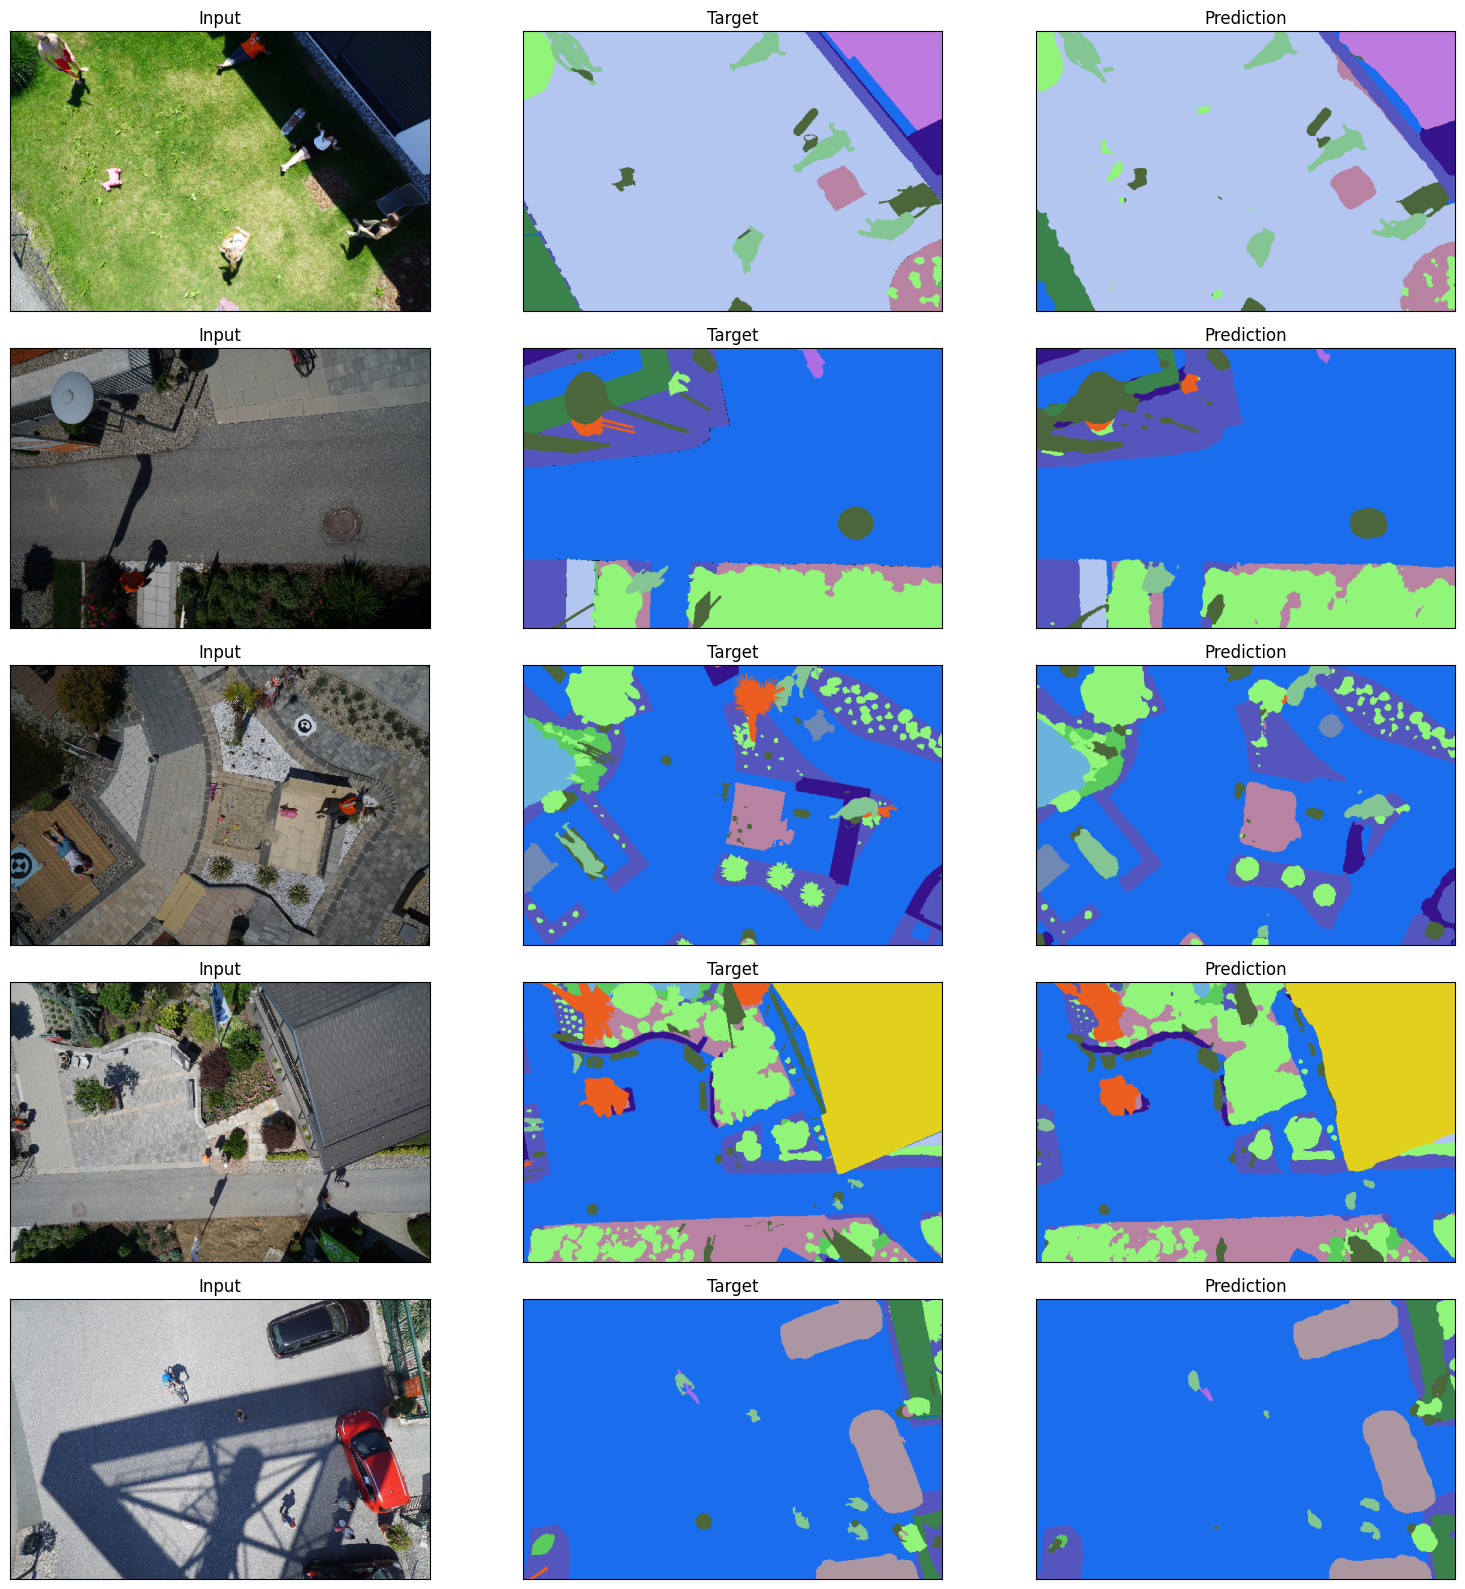

In [42]:
from deepml.transforms import ImageNetInverseTransform

segmentation_task.show_predictions(valid_loader, samples=5, image_inverse_transform=ImageNetInverseTransform())

### 11.1 Load the Best Val Loss Model Weights

In [43]:
!ls -l $wandb.run.dir

total 8869720
-rw-r--r-- 1 root root 756874289 Apr 21 14:53 best_val_model.pt
-rw-r--r-- 1 root root 756874289 Apr 21 14:15 epoch_10_model.pt
-rw-r--r-- 1 root root 756874289 Apr 21 14:22 epoch_15_model.pt
-rw-r--r-- 1 root root 756874289 Apr 21 14:28 epoch_20_model.pt
-rw-r--r-- 1 root root 756874289 Apr 21 14:35 epoch_25_model.pt
-rw-r--r-- 1 root root 756874289 Apr 21 14:43 epoch_30_model.pt
-rw-r--r-- 1 root root 756874289 Apr 21 14:50 epoch_35_model.pt
-rw-r--r-- 1 root root 756874289 Apr 21 14:56 epoch_40_model.pt
-rw-r--r-- 1 root root 756874289 Apr 21 15:01 epoch_45_model.pt
-rw-r--r-- 1 root root 756874289 Apr 21 15:06 epoch_50_model.pt
-rw-r--r-- 1 root root 756871075 Apr 21 14:06 epoch_5_model.pt
-rw-r--r-- 1 root root 756867861 Apr 21 15:06 latest_model.pt
drwxr-xr-x 3 root root      4096 Apr 21 13:58 media
-rw-r--r-- 1 root root     17229 Apr 21 15:13 output.log
-rw-r--r-- 1 root root     14968 Apr 21 13:57 requirements.txt
-rw-r--r-- 1 root root       981 Apr 21 13:57 wan

In [44]:
segmentation_task = HuggingFaceTask(model,
                                    model_dir=wandb.run.dir,
                                    load_saved_model=True,
                                    model_file_name="best_val_model.pt",
                                    )

Loading Saved Model Weights: /content/wandb/run-20260421_135723-c7uwl8q1/files/best_val_model.pt
Model Weights Successfully Loaded!


### 11.2 Get Validation Dataloader

In [45]:
# Load validation Dataloader.
_, valid_loader = get_dataloader(
    configs=HPARAMS,
    num_workers=TrainingConfig.NUM_WORKERS,
    shuffle_validation=True,
    pin_memory=GPU_AVAILABLE,
    custom_batch_size=InferenceConfig.BATCH_SIZE,
)

### 11.3 Evaluate Model

Get best evaluation metrics using the saved model and log them to WandB.

In [46]:
best_val_metrics = segmentation_task.evaluate(valid_loader, metrics={'best_val_meanIoU': MeanIoU(num_classes=DatasetConfig.NUM_CLASSES),
                                                  "best_val_loss": DiceCOELoss(num_classes=DatasetConfig.NUM_CLASSES)
                                                  })

best_val_metrics

Evaluation  : 100%|██████████| 10/10 [00:04<00:00,  2.09it/s]


{'best_val_meanIoU': 0.8306229829788208, 'best_val_loss': 0.3803536623716354}

In [47]:
for metric, val in best_val_metrics.items():
    wandb.run.summary[metric] = val

In [48]:
run.finish()

learning_rate,████████████████████▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss/train,█▄▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss/val,█▆▄▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
meanIoU/train,▁▄▅▆▆▇▇▇▇▇▇▇▇▇██████████████████████████
meanIoU/val,▁▂▄▄▆▆▇▇▇▇▇▇▇███████████████████████████
best_val_loss,0.38035
best_val_meanIoU,0.83062
learning_rate,3e-05
loss/train,0.20453
loss/val,0.38218
meanIoU/train,0.88458


## 12 Conclusion

In conclusion, this project successfully explored the application of semantic segmentation techniques on an Aerial Drone image dataset. The SegFormer segmentation model from the HuggingFace Transformers package was utilized, demonstrating its effectiveness in accurately segmenting aerial images. Custom metrics, including Intersection over Union (IoU), were defined and employed to evaluate the segmentation performance. The training process incorporated a combination loss function, combining Dice coefficient and cross entropy, to optimize both localization and classification accuracy. The MultiStepLr learning rate scheduler was employed to dynamically adjust the learning rate during training, enhancing convergence. Moreover, automatic mixed-precision training was utilized to improve computational efficiency by leveraging different numerical precisions. Additionally, the project leveraged WandB for experiment tracking, allowing for efficient monitoring and analysis of the training process. Overall, this project highlights the successful implementation of semantic segmentation techniques, utilizing advanced tools and methodologies, to achieve accurate and efficient segmentation on Aerial Drone images.